**Note:** This file exists purely for benchmarking and validating that nano-scBERT reproduces the behavior of the original scBERT implementation. If you're looking for installation instructions or a quick start guide, please head over to README.

In [1]:
import os, sys, time
from pathlib import Path

ROOT = Path(".")
SCBERT_DIR = ROOT / "scBERT"
NANO_DIR = ROOT / "nano-scBERT"
DATA_PATH = ROOT / "pancreas.h5ad"

sys.path.insert(0, str(SCBERT_DIR))
sys.path.insert(0, str(NANO_DIR))

print(DATA_PATH.exists())
print(SCBERT_DIR.exists())
print(NANO_DIR.exists())

True
True
True


# Download example scRNA data

In [9]:
import gdown

url = 'https://drive.google.com/uc?id=1ehxgfHTsMZXy6YzlFKGJOsBKQ5rrvMnd'
output = 'pancreas.h5ad'
gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1ehxgfHTsMZXy6YzlFKGJOsBKQ5rrvMnd
From (redirected): https://drive.google.com/uc?id=1ehxgfHTsMZXy6YzlFKGJOsBKQ5rrvMnd&confirm=t&uuid=ec79e3d0-21ba-44ce-9e3f-7bdf0eadf591
To: /aiau001_scratch/hqn0001/projects/rule11/pancreas.h5ad
100%|██████████████████████████████████████████| 126M/126M [00:01<00:00, 88.9MB/s]


'pancreas.h5ad'

# scBERT Data preprocessing

In [2]:
"""
pancreas.h5ad
    ↓
align gene order (16,906 genes)
    ↓
filter_cells(min_genes=200)
    ↓
normalize_total(1e4)
    ↓
log1p(base=2)
    ↓
pancreas_scbert_preprocessed.h5ad
"""

import sys
sys.path.insert(0, "./nano-scBERT")

from preprocessing import preprocess_adata
from registry import get_pretrained
from scBERT_tokenizer import scBERTTokenizer

import scanpy as sc

adata = sc.read_h5ad("./pancreas.h5ad")

tokenizer = scBERTTokenizer.from_pretrained(
    "scbert-human-panglao"
)

adata_pp = preprocess_adata(
    adata,
    tokenizer.genes,
)

adata_pp.write_h5ad(
    "./pancreas_scbert_preprocessed.h5ad"
)

print(adata_pp.shape)

Original genes: 1000 | Reference genes: 16906 | Matched genes: 933 (5.5%)
Cells after filtering: 4,146 | Genes: 16,906
(4146, 16906)


# official scBERT model

In [2]:
"""
pancreas_scbert_preprocessed.h5ad
    ↓
scBERT tokenization
    ↓
scBERT model
"""

!python ./scBERT/benchmark_official_scbert.py \
  --input ./pancreas_scbert_preprocessed.h5ad \
  --model_path ./scBERT/panglao_pretrain.pth \
  --output ./scbert_official_embeddings.npy \
  --batch_size 64 \
  --pool gene_mean



Loading data...
Input shape: (4146, 16906)
Loading official scBERT...
/aiau001_scratch/hqn0001/projects/rule11/scBERT/performer_pytorch/performer_pytorch.py:115: UserWarning: torch.qr is deprecated in favor of torch.linalg.qr and will be removed in a future PyTorch release.
The boolean parameter 'some' has been replaced with a string parameter 'mode'.
Q, R = torch.qr(A, some)
should be replaced with
Q, R = torch.linalg.qr(A, 'reduced' if some else 'complete') (Triggered internally at /pytorch/aten/src/ATen/native/BatchLinearAlgebra.cpp:2496.)
  q, r = torch.qr(unstructured_block.cpu(), some = True)
Warmup...
Average data loading time per batch: 0.0107 seconds
Average model inference time per batch: 2.0291 seconds
Total time for 4146 cells: 132.64 sec, 31.992 ms/cell
Saved torch.Size([4146, 200]) to ./scbert_official_embeddings.npy


# nano-scBERT model

In [ ]:
"""
pancreas_scbert_preprocessed.h5ad
    ↓
nano-scBERT tokenizer
    ↓
nano-scBERT model
"""

!python ./nano-scBERT/benchmark_nano_scbert.py \
  --input ./pancreas_scbert_preprocessed.h5ad \
  --output ./nano_scbert_embeddings.npy \
  --model scbert-human-panglao \
  --batch_size 64 \
  --pool gene_mean \
  --mode preprocessed 

Loading data...
Input shape: (4146, 16906)
Skipping preprocessing (already preprocessed).
Tokenizing data...
Token range: [0, 5]
Loading nano-scBERT...
Compiling model...
use_amp=True, use_compile=True
Warmup...
Average data loading time per batch: 0.0034 seconds
Average model inference time per batch: 0.8222 seconds
Total time for 4146 cells: 53.71 sec, 12.955 ms/cell
Throughput: 77.19 cells/s
Peak GPU memory: 19.965 GB
Saved (4146, 200) to ./nano_scbert_embeddings.npy


In [ ]:
import numpy as np
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist


# load embeddings
emb_official = np.load("./scbert_official_embeddings.npy")
emb_nano = np.load("./nano_scbert_embeddings.npy")

assert emb_official.shape == emb_nano.shape


# cosine similarity
# embeddings were already L2-normalized before save
cos = np.sum(
    emb_official * emb_nano,
    axis=1,
)

print("shape:", emb_official.shape)

print("mean cosine:", cos.mean())
print("median cosine:", np.median(cos))
print("min cosine:", cos.min())

print(
    "max abs diff:",
    np.abs(emb_official - emb_nano).max(),
)

print(
    "mean abs diff:",
    np.abs(emb_official - emb_nano).mean(),
)

# norm sanity check
print("\nofficial norm")
print(
    np.min(np.linalg.norm(emb_official, axis=1)),
    np.mean(np.linalg.norm(emb_official, axis=1)),
    np.max(np.linalg.norm(emb_official, axis=1)),
)

print("\nnano norm")
print(
    np.min(np.linalg.norm(emb_nano, axis=1)),
    np.mean(np.linalg.norm(emb_nano, axis=1)),
    np.max(np.linalg.norm(emb_nano, axis=1)),
)

print("\nmax norm error official")
print(
    np.max(
        np.abs(
            np.linalg.norm(emb_official, axis=1) - 1
        )
    )
)

print("\nmax norm error nano")
print(
    np.max(
        np.abs(
            np.linalg.norm(emb_nano, axis=1) - 1
        )
    )
)


# PCA variance spectrum
pca_off = PCA()
pca_off.fit(emb_official)

pca_nano = PCA()
pca_nano.fit(emb_nano)

print("\nofficial first 10 PCs")
print(pca_off.explained_variance_ratio_[:10])

print("\nnano first 10 PCs")
print(pca_nano.explained_variance_ratio_[:10])

# pairwise distance preservation
np.random.seed(0)

idx = np.random.choice(
    len(emb_nano),
    1000,
    replace=False,
)

d1 = pdist(emb_official[idx])
d2 = pdist(emb_nano[idx])

corr = np.corrcoef(d1, d2)[0, 1]

print("\ndistance correlation =", corr)

shape: (4146, 200)
mean cosine: 1.0
median cosine: 1.0
min cosine: 0.99999976
max abs diff: 2.7015805e-05
mean abs diff: 2.7436167e-06

official norm
0.9999999 1.0 1.0000001

nano norm
0.9999999 1.0 1.0000001

max norm error official
1.1920929e-07

max norm error nano
1.1920929e-07

official first 10 PCs
[6.0642678e-01 3.4930193e-01 2.4396177e-02 1.1948564e-02 2.4247190e-03
 1.5831394e-03 1.1930260e-03 9.1455982e-04 6.1017176e-04 2.2873738e-04]

nano first 10 PCs
[6.0639209e-01 3.4937167e-01 2.4391074e-02 1.1944633e-02 2.4203034e-03
 1.5891015e-03 1.1642250e-03 9.1512449e-04 6.1662548e-04 2.2926937e-04]

distance correlation = 0.9999997518302555


/home/cse_h2/hqn0001/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using label key: cell_type
Embedding shape: (4146, 200)
mean cosine: 1.0
median cosine: 1.0
min cosine: 0.9999999
max abs diff: 2.7015805e-05
mean abs diff: 2.7436156e-06


/aiau001_scratch/hqn0001/envs/hub/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


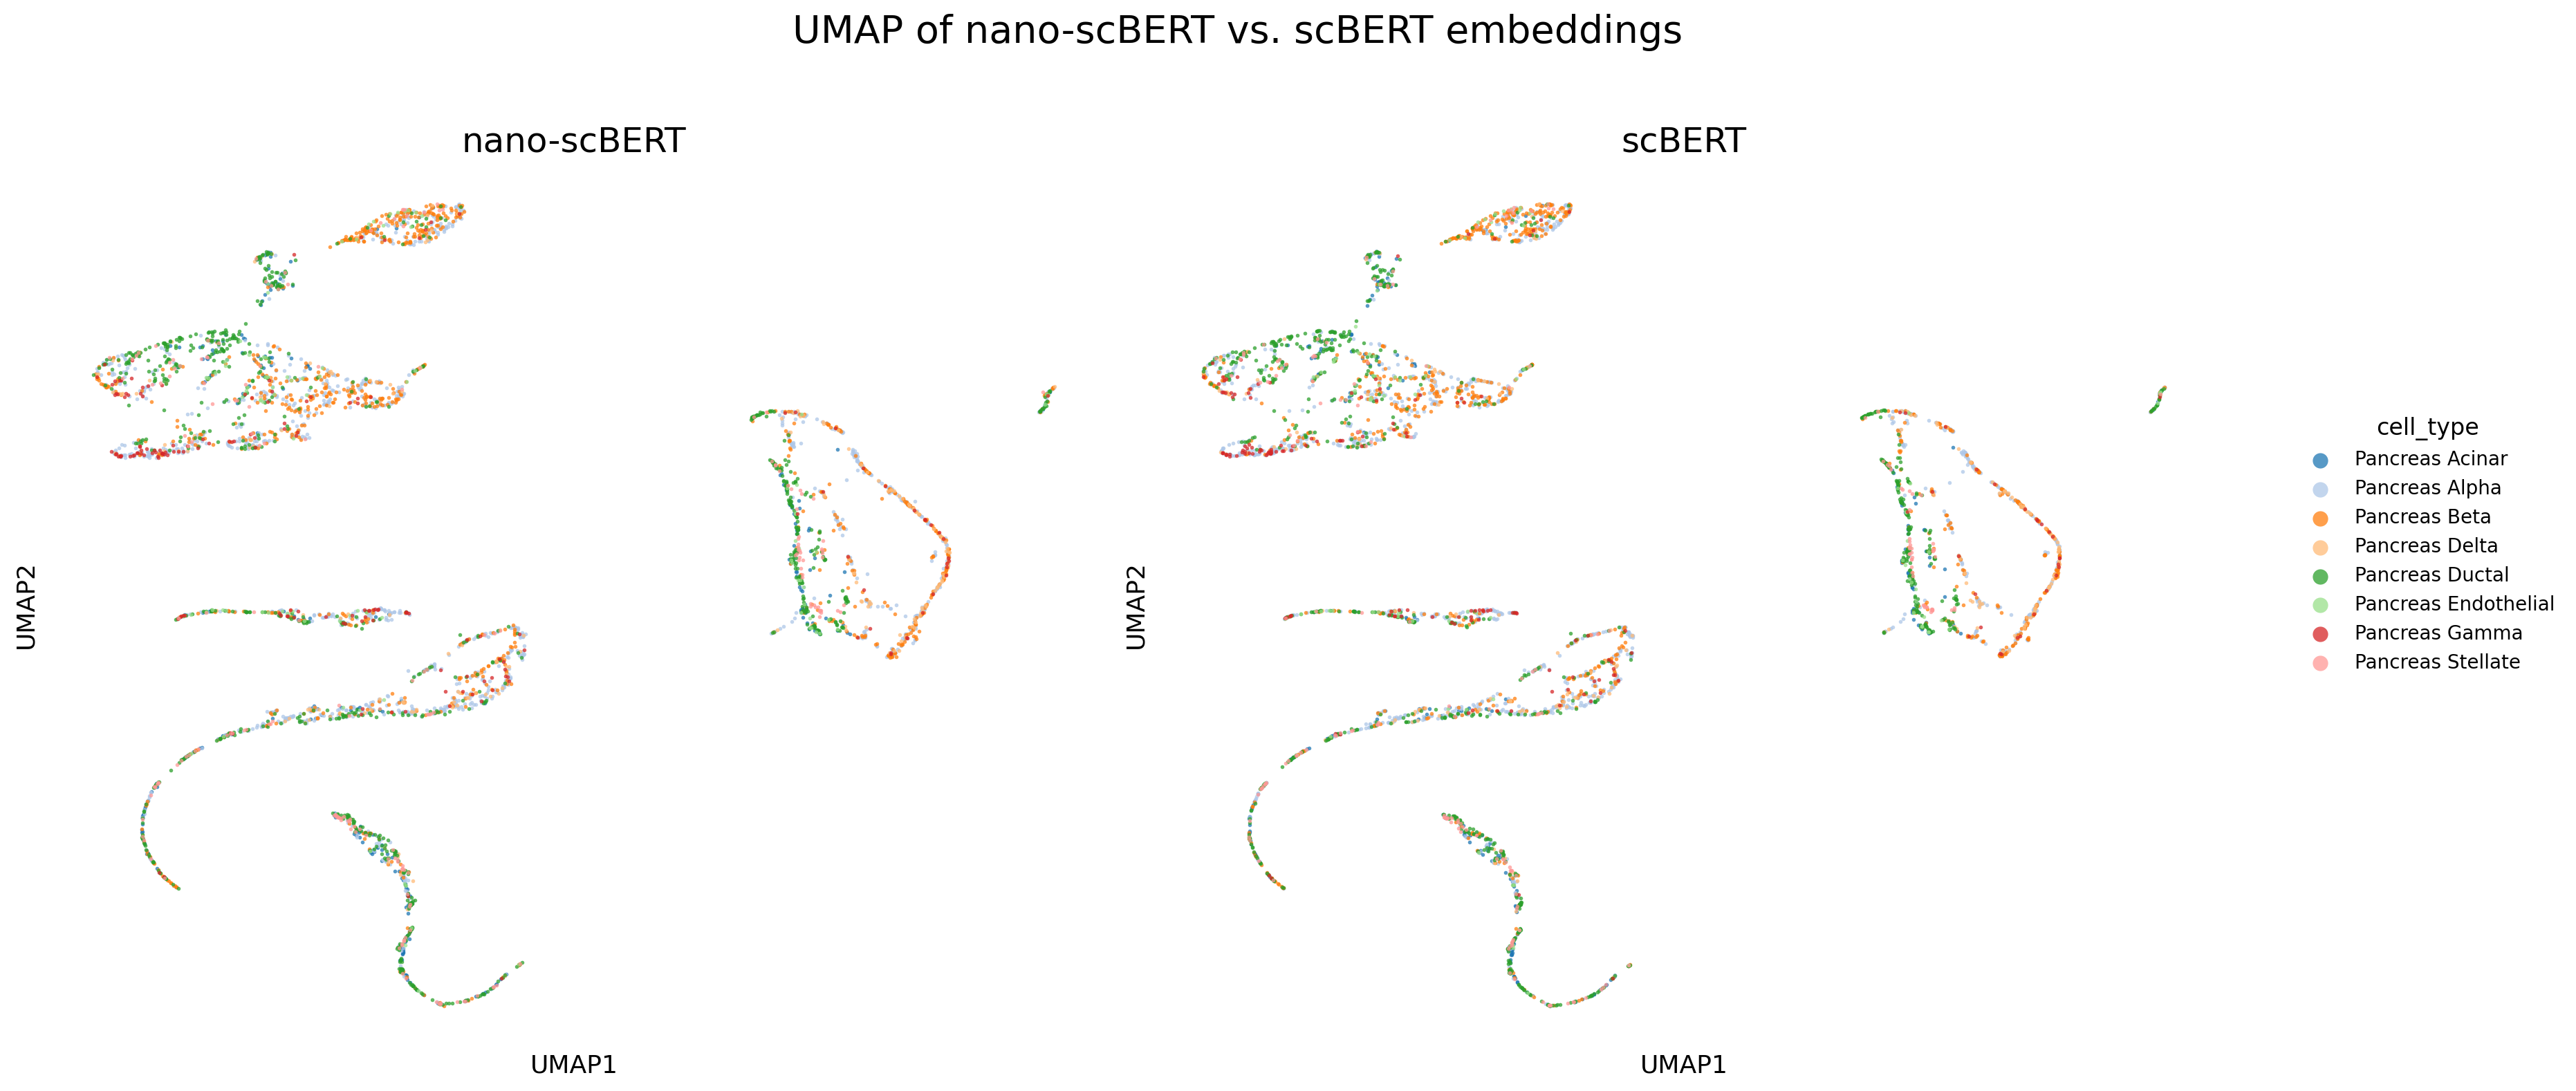

Saved: ./umap_nano_scbert_vs_scbert.png


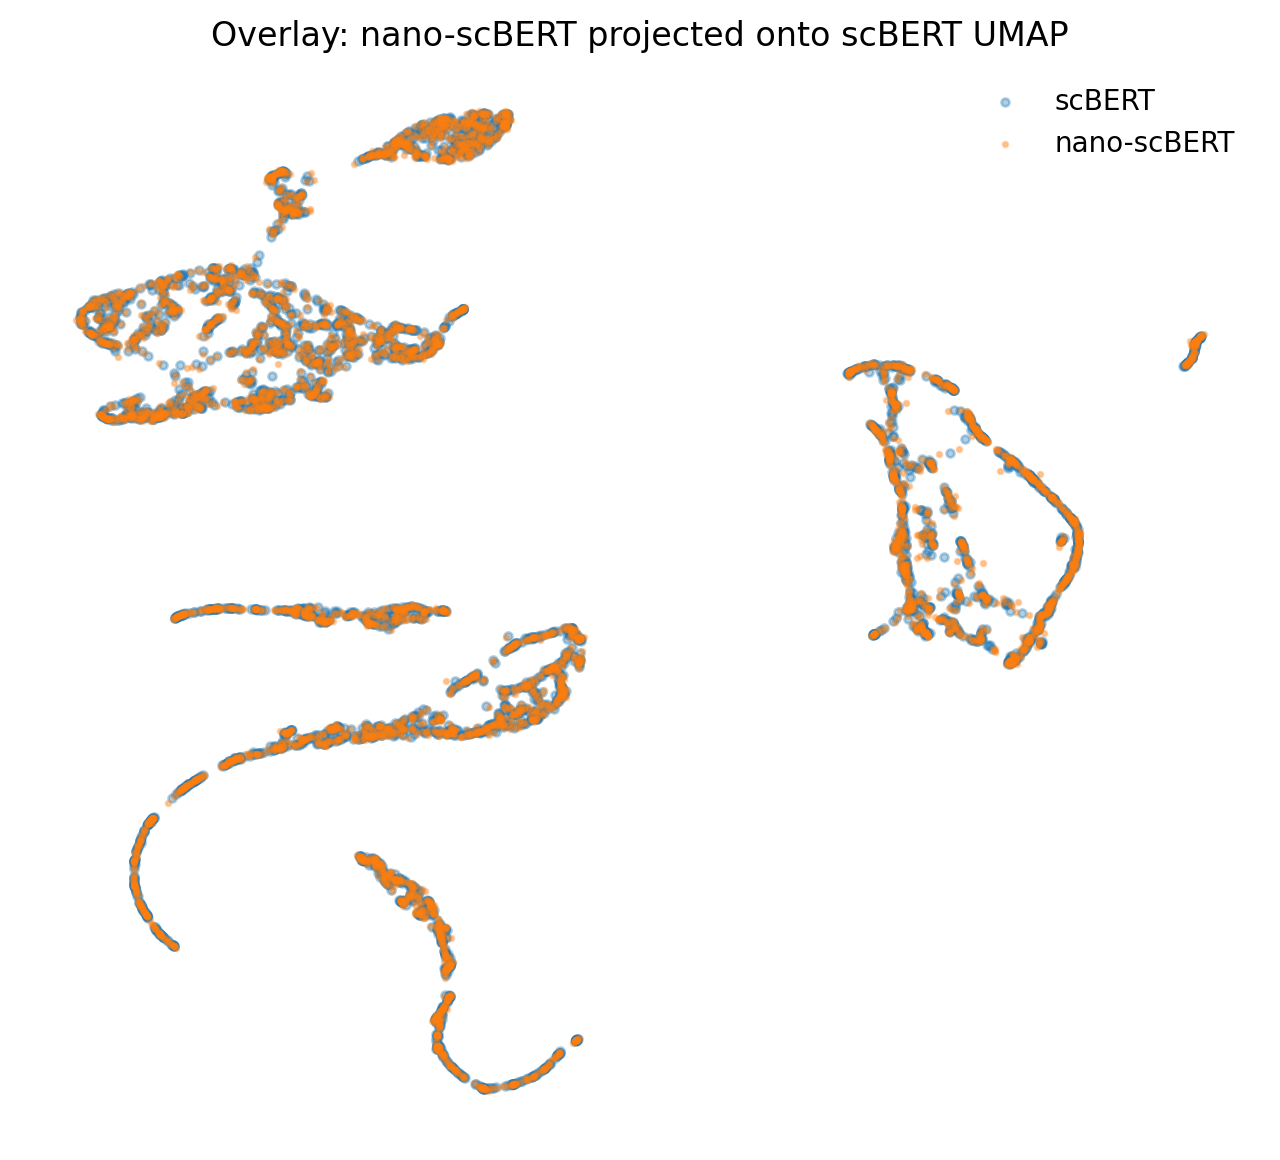

Saved: ./umap_overlay_nano_scbert_vs_scbert.png


In [ ]:
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import umap
from pathlib import Path

# paths
official_path = Path("./scbert_official_embeddings.npy")
nano_path = Path("./nano_scbert_embeddings.npy")
adata_path = Path("./pancreas_scbert_preprocessed.h5ad")

# load
emb_official = np.load(official_path)
emb_nano = np.load(nano_path)
adata = sc.read_h5ad(adata_path)

assert emb_official.shape == emb_nano.shape
assert emb_official.shape[0] == adata.n_obs

# labels
possible_keys = ["celltype", "cell_type", "CellType", "broad_cell_class", "broad cell class"]

label_key = None
for k in possible_keys:
    if k in adata.obs.columns:
        label_key = k
        break

if label_key is None:
    raise ValueError(f"Cannot find cell type column. Available obs columns: {list(adata.obs.columns)}")

labels = adata.obs[label_key].astype(str).values
classes = np.unique(labels)

print("Using label key:", label_key)
print("Embedding shape:", emb_nano.shape)

# normalize
def l2norm(x):
    return x / np.linalg.norm(x, axis=1, keepdims=True)

emb_official_n = l2norm(emb_official)
emb_nano_n = l2norm(emb_nano)

#  metrics 
cos = np.sum(emb_official_n * emb_nano_n, axis=1)
abs_diff = np.abs(emb_official_n - emb_nano_n)

print("mean cosine:", cos.mean())
print("median cosine:", np.median(cos))
print("min cosine:", cos.min())
print("max abs diff:", abs_diff.max())
print("mean abs diff:", abs_diff.mean())

# UMAP 
# Fit UMAP on official scBERT, then project nano-scBERT into same UMAP space
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=0,
)

xy_official = reducer.fit_transform(emb_official_n)
xy_nano = reducer.transform(emb_nano_n)

# side-by-side plot 
fig, axes = plt.subplots(1, 2, figsize=(18, 8), dpi=200)

cmap = plt.get_cmap("tab20")
color_map = {c: cmap(i % 20) for i, c in enumerate(classes)}

for ax, xy_i, title in [
    (axes[0], xy_nano, "nano-scBERT"),
    (axes[1], xy_official, "scBERT"),
]:
    for c in classes:
        idx = labels == c
        ax.scatter(
            xy_i[idx, 0],
            xy_i[idx, 1],
            s=4,
            alpha=0.75,
            color=color_map[c],
            label=c,
            linewidths=0,
        )

    ax.set_title(title, fontsize=18)
    ax.set_xlabel("UMAP1", fontsize=13)
    ax.set_ylabel("UMAP2", fontsize=13)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)

handles, legend_labels = axes[1].get_legend_handles_labels()

fig.legend(
    handles,
    legend_labels,
    title=label_key,
    loc="center left",
    bbox_to_anchor=(0.92, 0.5),
    frameon=False,
    markerscale=4,
    fontsize=10,
    title_fontsize=12,
)

fig.suptitle(
    "UMAP of nano-scBERT vs. scBERT embeddings",
    fontsize=20,
    y=0.98,
)

plt.tight_layout(rect=[0, 0, 0.9, 0.95])

out_png = "./umap_nano_scbert_vs_scbert.png"
plt.savefig(out_png, bbox_inches="tight")
plt.show()

print("Saved:", out_png)

# ---------- overlay plot ----------
plt.figure(figsize=(8, 7), dpi=200)
plt.scatter(
    xy_official[:, 0],
    xy_official[:, 1],
    s=8,
    alpha=0.35,
    label="scBERT",
)
plt.scatter(
    xy_nano[:, 0],
    xy_nano[:, 1],
    s=3,
    alpha=0.35,
    label="nano-scBERT",
)
plt.legend(frameon=False)
plt.title("Overlay: nano-scBERT projected onto scBERT UMAP")
plt.xticks([])
plt.yticks([])
plt.axis("off")

out_overlay = "./umap_overlay_nano_scbert_vs_scbert.png"
plt.savefig(out_overlay, bbox_inches="tight")
plt.show()

print("Saved:", out_overlay)